<a href="https://colab.research.google.com/github/Manikanta-23-ai/Machine-Learning-Projects/blob/main/ZOMATO_DATA_ANLAYSIS_USING_PYTHON.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:

#Importing Libraries
import numpy as np
import pandas as pd
import seaborn as sb
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LogisticRegression
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report
from sklearn.metrics import confusion_matrix

In [3]:
import pandas as pd

df = pd.read_csv(
    "/content/zomato.csv",
    engine="python",
    on_bad_lines="skip",
    dtype=str
)


In [4]:
df.head()

,url,address,name,online_order,book_table,rate,votes,phone,location,rest_type,dish_liked,cuisines,approx_cost(for two people),reviews_list,menu_item,listed_in(type),listed_in(city)
0,https://www.zomato.com/bangalore/jalsa-banasha...,"942, 21st Main Road, 2nd Stage, Banashankari, ...",Jalsa,Yes,Yes,4.1/5,775,080 42297555\r\n+91 9743772233,Banashankari,Casual Dining,"Pasta, Lunch Buffet, Masala Papad, Paneer Laja...","North Indian, Mughlai, Chinese",800,"[('Rated 4.0', 'RATED\n A beautiful place to ...",[],Buffet,Banashankari
1,https://www.zomato.com/bangalore/spice-elephan...,"2nd Floor, 80 Feet Road, Near Big Bazaar, 6th ...",Spice Elephant,Yes,No,4.1/5,787,080 41714161,Banashankari,Casual Dining,"Momos, Lunch Buffet, Chocolate Nirvana, Thai G...","Chinese, North Indian, Thai",800,"[('Rated 4.0', 'RATED\n Had been here for din...",[],Buffet,Banashankari
2,https://www.zomato.com/SanchurroBangalore?cont...,"1112, Next to KIMS Medical College, 17th Cross...",San Churro Cafe,Yes,No,3.8/5,918,+91 9663487993,Banashankari,"Cafe, Casual Dining","Churros, Cannelloni, Minestrone Soup, Hot Choc...","Cafe, Mexican, Italian",800,"[('Rated 3.0', ""RATED\n Ambience is not that ...",[],Buffet,Banashankari
3,https://www.zomato.com/bangalore/addhuri-udupi...,"1st Floor, Annakuteera, 3rd Stage, Banashankar...",Addhuri Udupi Bhojana,No,No,3.7/5,88,+91 9620009302,Banashankari,Quick Bites,Masala Dosa,"South Indian, North Indian",300,"[('Rated 4.0', ""RATED\n Great food and proper...",[],Buffet,Banashankari
4,https://www.zomato.com/bangalore/grand-village...,"10, 3rd Floor, Lakshmi Associates, Gandhi Baza...",Grand Village,No,No,3.8/5,166,+91 8026612447\r\n+91 9901210005,Basavanagudi,Casual Dining,"Panipuri, Gol Gappe","North Indian, Rajasthani",600,"[('Rated 4.0', 'RATED\n Very good restaurant ...",[],Buffet,Banashankari


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2650 entries, 0 to 2649
Data columns (total 17 columns):
 #   Column                       Non-Null Count  Dtype 
---  ------                       --------------  ----- 
 0   url                          2650 non-null   object
 1   address                      2650 non-null   object
 2   name                         2650 non-null   object
 3   online_order                 2650 non-null   object
 4   book_table                   2650 non-null   object
 5   rate                         2270 non-null   object
 6   votes                        2650 non-null   object
 7   phone                        2613 non-null   object
 8   location                     2649 non-null   object
 9   rest_type                    2637 non-null   object
 10  dish_liked                   1052 non-null   object
 11  cuisines                     2646 non-null   object
 12  approx_cost(for two people)  2647 non-null   object
 13  reviews_list                 2650

In [6]:
df.describe()

,url,address,name,online_order,book_table,rate,votes,phone,location,rest_type,dish_liked,cuisines,approx_cost(for two people),reviews_list,menu_item,listed_in(type),listed_in(city)
count,2650,2650,2650,2650,2650,2270,2650,2613,2649,2637,1052,2646,2647,2650,2650,2650,2650
unique,2650,1651,1546,2,2,28,462,1768,24,50,615,645,35,1657,380,6,3
top,https://www.zomato.com/bangalore/bhojohori-man...,"1260, SY 35/4, SJR Tower's, 7th Phase, 24th Ma...",Five Star Chicken,Yes,No,3.8/5,0,080 43334321,Bannerghatta Road,Quick Bites,Biryani,South Indian,300,[],[],Delivery,Bannerghatta Road
freq,1,7,9,1702,2461,228,541,24,760,1120,14,147,410,390,2256,1483,1615


In [7]:
z=df.drop(['url','dish_liked','phone'],axis=1)

In [8]:
#Removing the Duplicates
z.duplicated().sum()
z.drop_duplicates(inplace=True)

In [9]:
#Remove the NaN valuesin the dataset
z.isnull().sum()
z.dropna(how='any',inplace=True)
z.info()

<class 'pandas.core.frame.DataFrame'>
Index: 2260 entries, 0 to 2649
Data columns (total 14 columns):
 #   Column                       Non-Null Count  Dtype 
---  ------                       --------------  ----- 
 0   address                      2260 non-null   object
 1   name                         2260 non-null   object
 2   online_order                 2260 non-null   object
 3   book_table                   2260 non-null   object
 4   rate                         2260 non-null   object
 5   votes                        2260 non-null   object
 6   location                     2260 non-null   object
 7   rest_type                    2260 non-null   object
 8   cuisines                     2260 non-null   object
 9   approx_cost(for two people)  2260 non-null   object
 10  reviews_list                 2260 non-null   object
 11  menu_item                    2260 non-null   object
 12  listed_in(type)              2260 non-null   object
 13  listed_in(city)              2260 non-

In [10]:
z.columns

Index(['address', 'name', 'online_order', 'book_table', 'rate', 'votes',
       'location', 'rest_type', 'cuisines', 'approx_cost(for two people)',
       'reviews_list', 'menu_item', 'listed_in(type)', 'listed_in(city)'],
      dtype='object')

In [11]:
z.info()

<class 'pandas.core.frame.DataFrame'>
Index: 2260 entries, 0 to 2649
Data columns (total 14 columns):
 #   Column                       Non-Null Count  Dtype 
---  ------                       --------------  ----- 
 0   address                      2260 non-null   object
 1   name                         2260 non-null   object
 2   online_order                 2260 non-null   object
 3   book_table                   2260 non-null   object
 4   rate                         2260 non-null   object
 5   votes                        2260 non-null   object
 6   location                     2260 non-null   object
 7   rest_type                    2260 non-null   object
 8   cuisines                     2260 non-null   object
 9   approx_cost(for two people)  2260 non-null   object
 10  reviews_list                 2260 non-null   object
 11  menu_item                    2260 non-null   object
 12  listed_in(type)              2260 non-null   object
 13  listed_in(city)              2260 non-

In [12]:
#Changing the column names
z = z.rename(columns={'approx_cost(for two people)':'cost','listed_in(type)':'type',
                                  'listed_in(city)':'city'})
z.columns

Index(['address', 'name', 'online_order', 'book_table', 'rate', 'votes',
       'location', 'rest_type', 'cuisines', 'cost', 'reviews_list',
       'menu_item', 'type', 'city'],
      dtype='object')

In [13]:
z.columns

Index(['address', 'name', 'online_order', 'book_table', 'rate', 'votes',
       'location', 'rest_type', 'cuisines', 'cost', 'reviews_list',
       'menu_item', 'type', 'city'],
      dtype='object')

In [14]:
z['cost'] = z['cost'].astype(str) #Changing the cost to string
z['cost'] = z['cost'].apply(lambda x: x.replace(',','.')) #Using lambda function to replace ',' from cost
z['cost'] = z['cost'].astype(float) # Changing the cost to Float
z.info()

<class 'pandas.core.frame.DataFrame'>
Index: 2260 entries, 0 to 2649
Data columns (total 14 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   address       2260 non-null   object 
 1   name          2260 non-null   object 
 2   online_order  2260 non-null   object 
 3   book_table    2260 non-null   object 
 4   rate          2260 non-null   object 
 5   votes         2260 non-null   object 
 6   location      2260 non-null   object 
 7   rest_type     2260 non-null   object 
 8   cuisines      2260 non-null   object 
 9   cost          2260 non-null   float64
 10  reviews_list  2260 non-null   object 
 11  menu_item     2260 non-null   object 
 12  type          2260 non-null   object 
 13  city          2260 non-null   object 
dtypes: float64(1), object(13)
memory usage: 264.8+ KB


In [15]:
z['rate'].unique()

array(['4.1/5', '3.8/5', '3.7/5', '3.6/5', '4.6/5', '4.0/5', '4.2/5',
       '3.9/5', '3.1/5', '3.0/5', '3.2/5', '3.3/5', '2.8/5', '4.4/5',
       '4.3/5', 'NEW', '2.9/5', '3.5/5', '2.6/5', '3.8 /5', '3.4/5',
       '4.5/5', '2.5/5', '2.7/5', '4.7/5', '2.4/5', '2.2/5', '2.3/5'],
      dtype=object)

In [16]:
import numpy as np
np.str = str

zomato = z.loc[z.rate !='NEW']
zomato = zomato.loc[zomato.rate !='-'].reset_index(drop=True)
remove_slash = lambda x: x.replace('/5', '') if type(x) == np.str else x
zomato.rate = zomato.rate.apply(remove_slash).str.strip().astype('float')
zomato['rate'].head()

,rate
0,4.1
1,4.1
2,3.8
3,3.7
4,3.8


In [17]:
zomato.name = zomato.name.apply(lambda x:x.title())
zomato.online_order.replace(('Yes','No'),(True, False),inplace=True)
zomato.book_table.replace(('Yes','No'),(True, False),inplace=True)
zomato.cost.unique()

/tmp/ipython-input-1930664921.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  zomato.online_order.replace(('Yes','No'),(True, False),inplace=True)
/tmp/ipython-input-1930664921.py:2: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  zomato.online_order.replace(('Yes','No'),(True, False),inplace=True

array([800.  , 300.  , 600.  , 700.  , 550.  , 500.  , 450.  , 650.  ,
       400.  , 900.  , 200.  , 750.  , 150.  , 850.  , 100.  ,   1.2 ,
       350.  , 250.  , 950.  ,   1.  ,   1.5 ,   1.3 , 199.  ,   1.1 ,
         1.6 , 230.  , 130.  ,   1.7 ,   1.35])

In [18]:
#Encode the input Variables
def Encode(zomato):
    for column in zomato.columns[~zomato.columns.isin(['rate', 'cost', 'votes'])]:
        zomato[column] = zomato[column].factorize()[0]
    return zomato

zomato_en = Encode(zomato.copy())

Index(['address', 'name', 'online_order', 'book_table', 'rate', 'votes',
       'location', 'rest_type', 'cuisines', 'cost', 'reviews_list',
       'menu_item', 'type', 'city'],
      dtype='object')

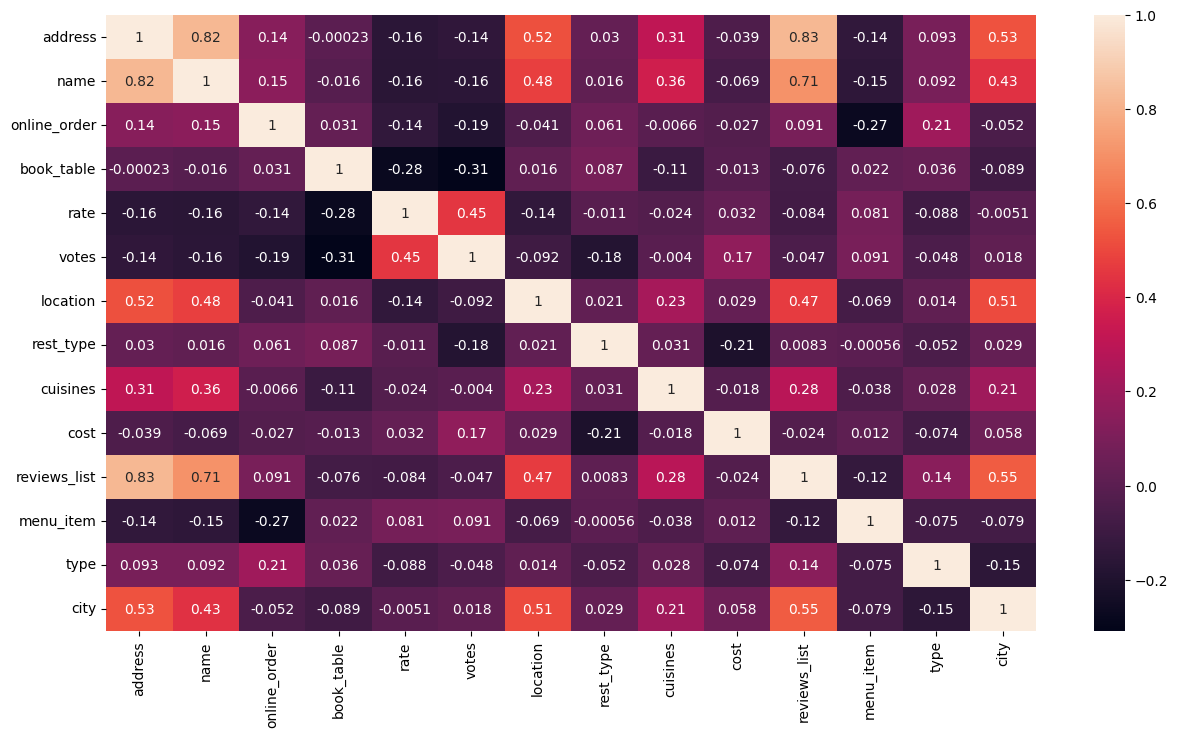

In [19]:
corr = zomato_en.corr(method='kendall')
plt.figure(figsize=(15,8))
sns.heatmap(corr, annot=True)
plt.savefig("correlation.png")
zomato_en.columns

In [20]:
#Defining the independent variables and dependent variables
x = zomato_en.iloc[:,[2,3,5,6,7,8,9,11]]
y = zomato_en['rate']
#Getting Test and Training Set
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=.1,random_state=353)
x_train.head()
y_train.head()

,rate
1381,3.4
925,3.1
308,3.6
1731,3.5
1114,3.4


In [21]:
#Prepare a Linear Regression Model
reg=LinearRegression()
reg.fit(x_train,y_train)
y_pred=reg.predict(x_test)
from sklearn.metrics import r2_score
r2_score(y_test,y_pred)

0.1779597399003663

In [22]:
from sklearn.ensemble import RandomForestRegressor
RForest=RandomForestRegressor(n_estimators=500,random_state=329,min_samples_leaf=.0001)
RForest.fit(x_train,y_train)
y_predict=RForest.predict(x_test)
from sklearn.metrics import r2_score
r2_score(y_test,y_predict)

0.6598035671703275

In [23]:
from sklearn.tree import DecisionTreeRegressor
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=.1,random_state=105)
DTree=DecisionTreeRegressor(min_samples_leaf=.0001)
DTree.fit(x_train,y_train)
y_predict=DTree.predict(x_test)
from sklearn.metrics import r2_score
r2_score(y_test,y_predict)

0.5235636922385039

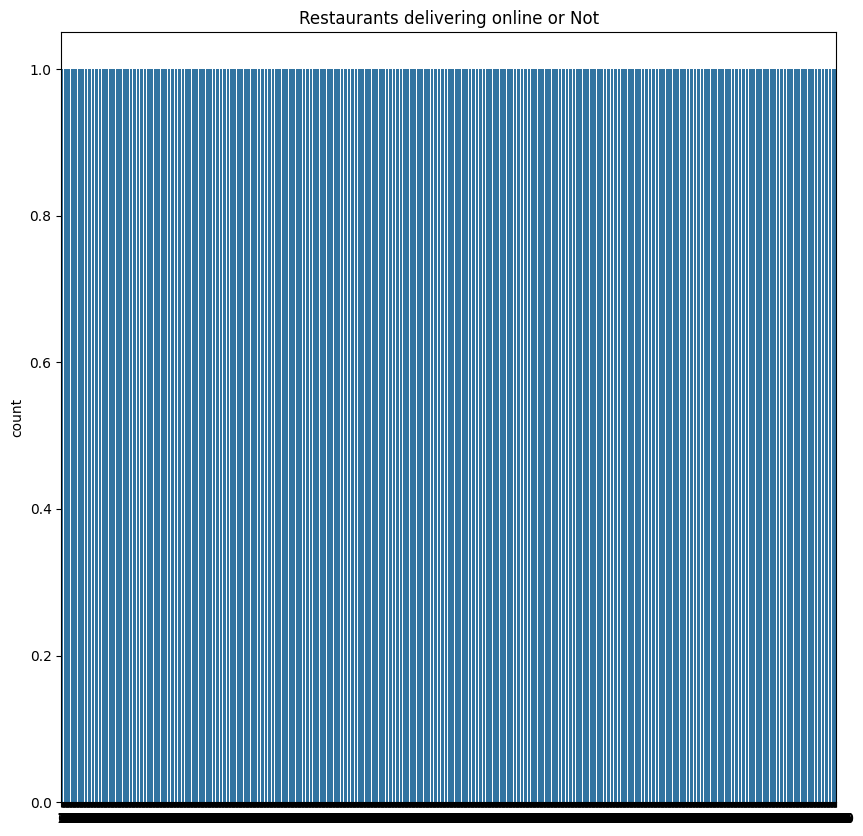

In [24]:
sns.countplot(zomato['online_order'])
fig = plt.gcf()
fig.set_size_inches(10,10)
plt.title('Restaurants delivering online or Not')
plt.savefig("online.png")

Text(0.5, 1.0, 'Restaurants allowing table booking or not')

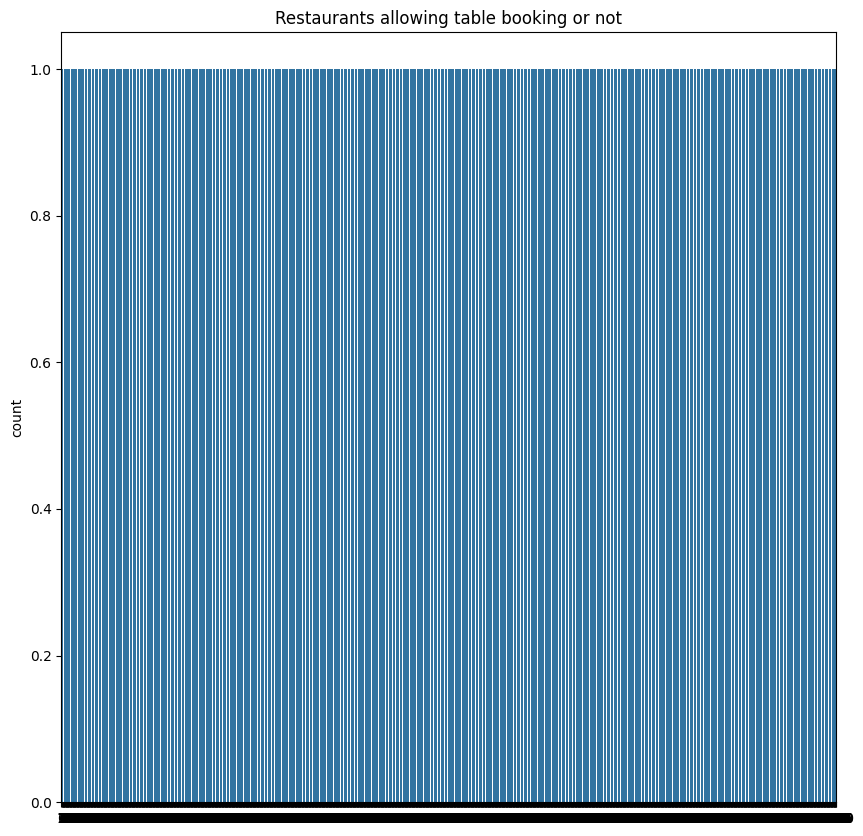

In [25]:
sns.countplot(zomato['book_table'])
fig = plt.gcf()
fig.set_size_inches(10,10)
plt.savefig("Book_Table.png")
plt.title('Restaurants allowing table booking or not')

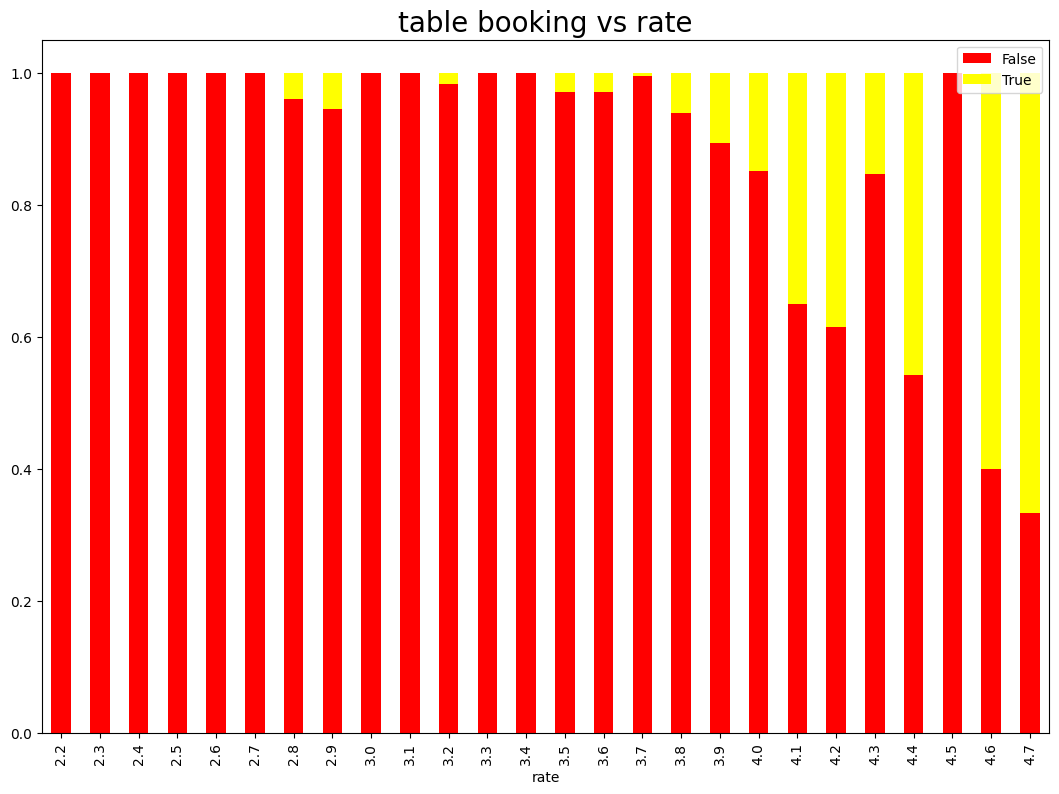

In [26]:
plt.rcParams['figure.figsize'] = (13, 9)
Y = pd.crosstab(zomato['rate'], zomato['book_table'])
Y.div(Y.sum(1).astype(float), axis = 0).plot(kind = 'bar', stacked = True,color=['red','yellow'])
plt.title('table booking vs rate', fontweight = 30, fontsize = 20)
plt.legend(loc="upper right")
plt.savefig("Table_Booking_Rate.png")
plt.show()

/tmp/ipython-input-1448218717.py:2: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  sns.countplot(zomato['city']).set_xticklabels(sns.countplot(zomato['city']).get_xticklabels(), rotation=90, ha="right")


Text(0.5, 1.0, 'Location')

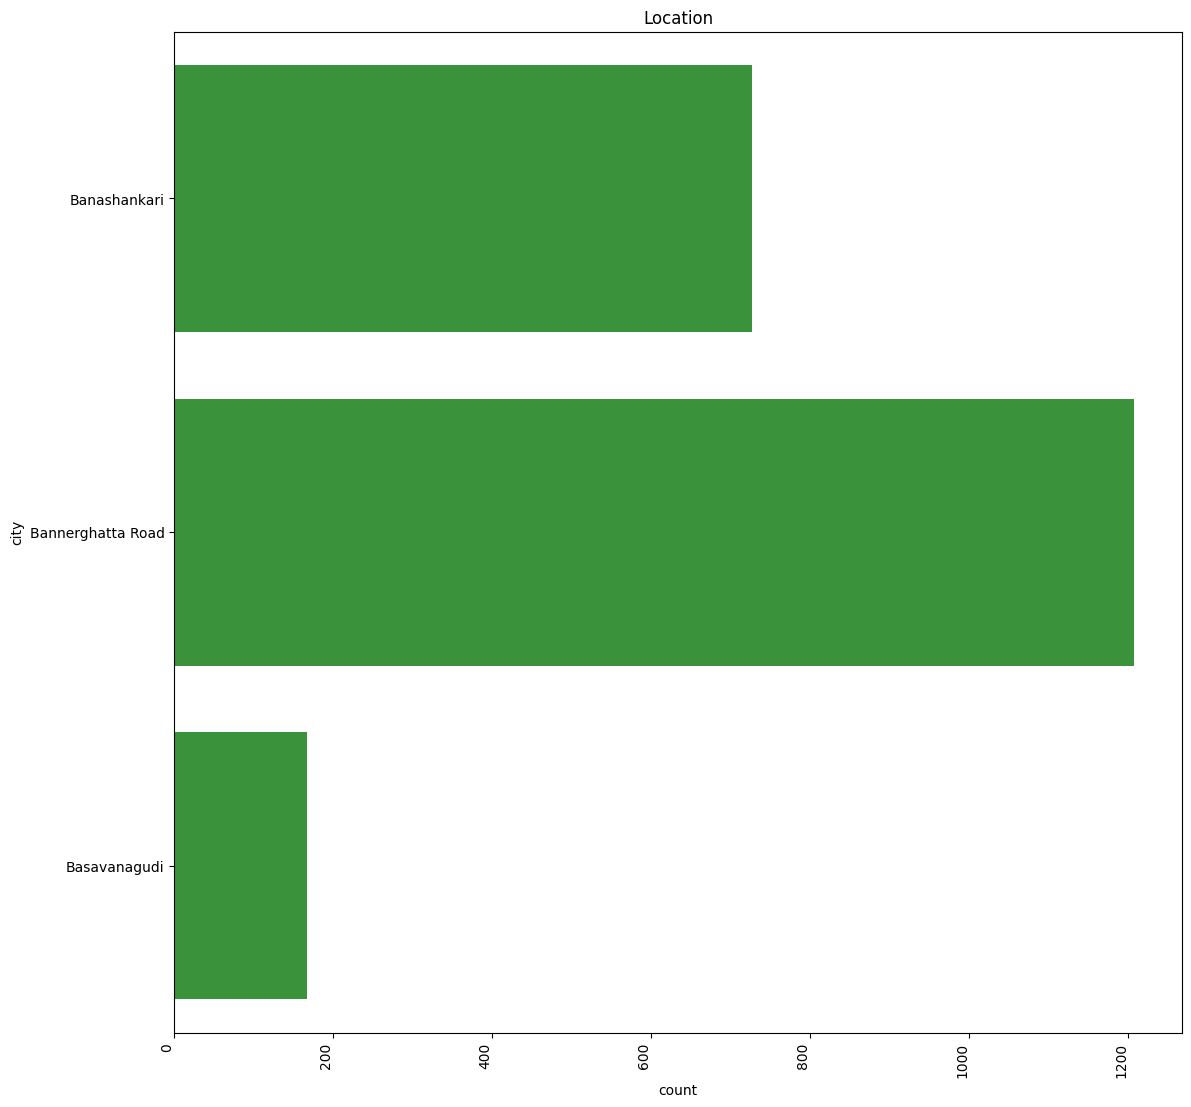

In [27]:
sns.countplot(zomato['city'])
sns.countplot(zomato['city']).set_xticklabels(sns.countplot(zomato['city']).get_xticklabels(), rotation=90, ha="right")
fig = plt.gcf()
fig.set_size_inches(13,13)
plt.savefig("Location.png")
plt.title('Location')

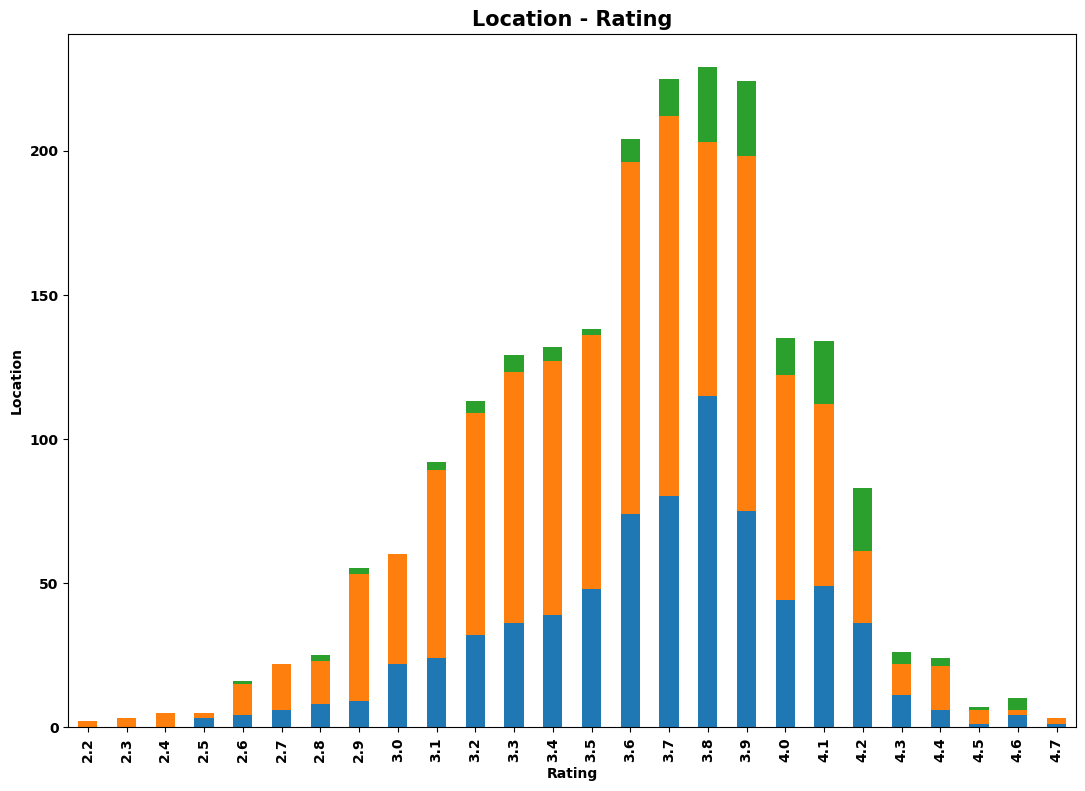

In [28]:
loc_plt=pd.crosstab(zomato['rate'],zomato['city'])
loc_plt.plot(kind='bar',stacked=True);
plt.title('Location - Rating',fontsize=15,fontweight='bold')
plt.ylabel('Location',fontsize=10,fontweight='bold')
plt.xlabel('Rating',fontsize=10,fontweight='bold')
plt.xticks(fontsize=10,fontweight='bold')
plt.yticks(fontsize=10,fontweight='bold');
plt.legend().remove();
plt.savefig("Location Rating.png")

/tmp/ipython-input-4092123779.py:2: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  sns.countplot(zomato['rest_type']).set_xticklabels(sns.countplot(zomato['rest_type']).get_xticklabels(), rotation=90, ha="right")


Text(0.5, 1.0, 'Restuarant Type')

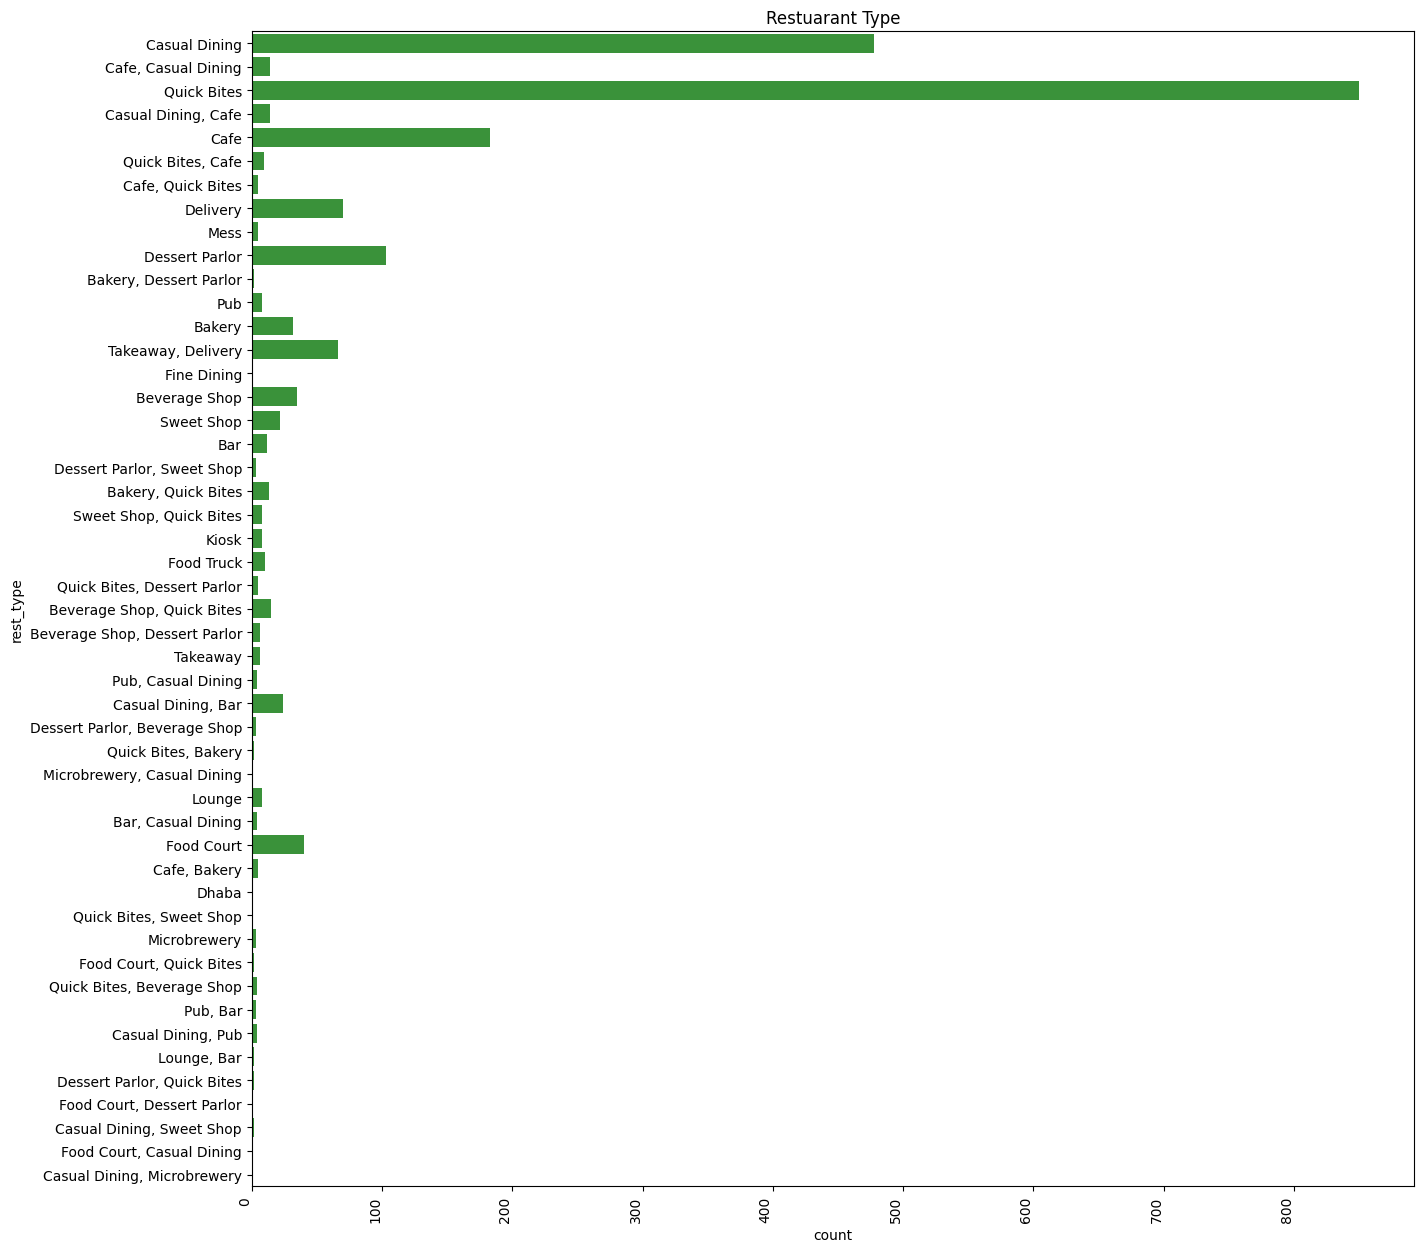

In [29]:
sns.countplot(zomato['rest_type'])
sns.countplot(zomato['rest_type']).set_xticklabels(sns.countplot(zomato['rest_type']).get_xticklabels(), rotation=90, ha="right")
fig = plt.gcf()
fig.set_size_inches(15,15)
plt.savefig("Restuarant Type")
plt.title('Restuarant Type')

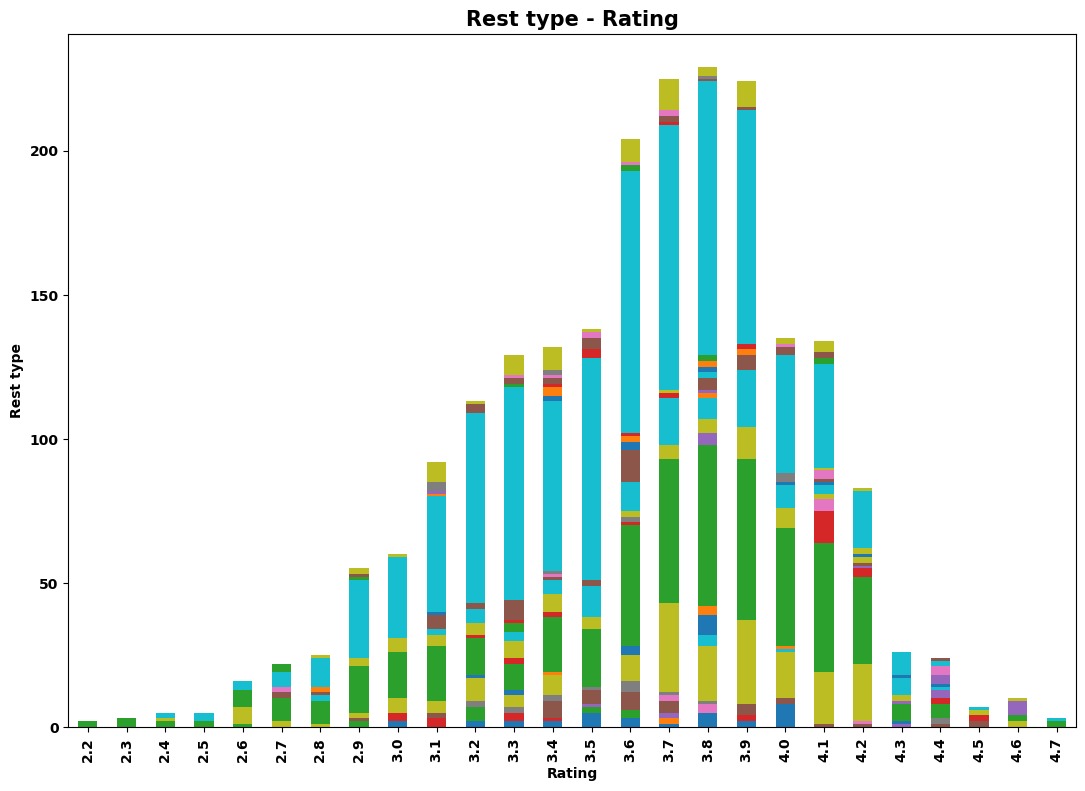

In [30]:
loc_plt=pd.crosstab(zomato['rate'],zomato['rest_type'])
loc_plt.plot(kind='bar',stacked=True);
plt.title('Rest type - Rating',fontsize=15,fontweight='bold')
plt.ylabel('Rest type',fontsize=10,fontweight='bold')
plt.xlabel('Rating',fontsize=10,fontweight='bold')
plt.xticks(fontsize=10,fontweight='bold')
plt.yticks(fontsize=10,fontweight='bold');
plt.legend().remove();
plt.savefig('Rest Type-Rating')

/tmp/ipython-input-2759970338.py:2: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  sns.countplot(zomato['type']).set_xticklabels(sns.countplot(zomato['type']).get_xticklabels(), rotation=90, ha="right")


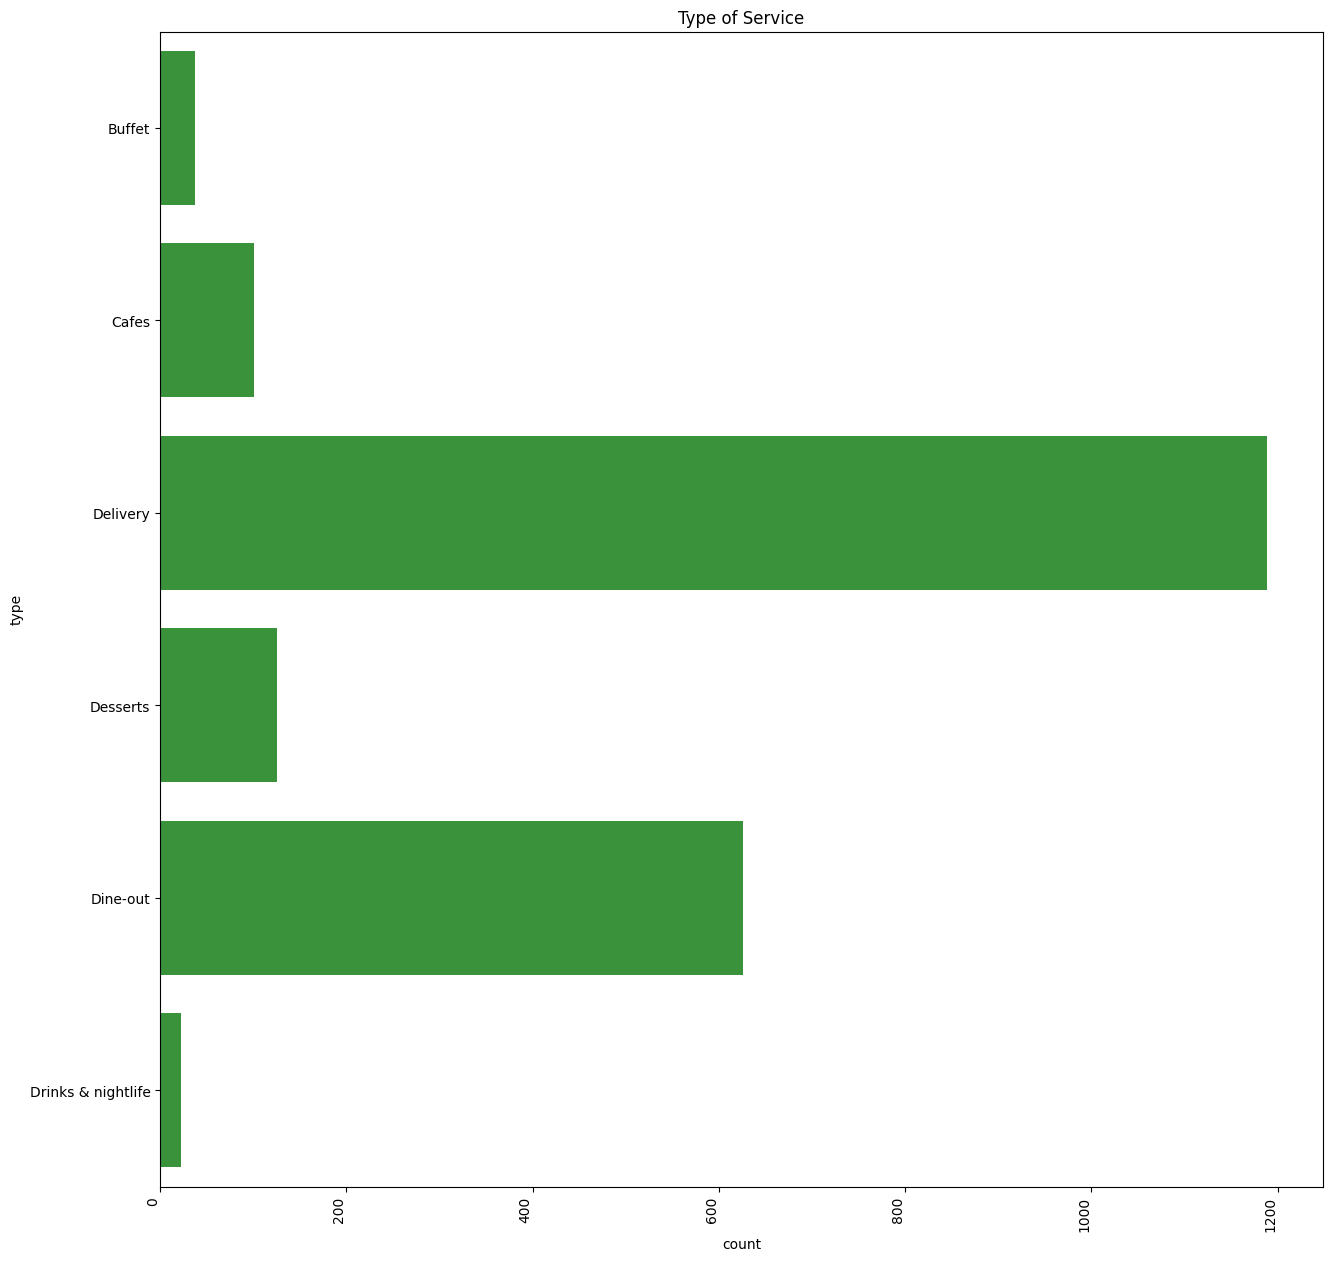

In [31]:
sns.countplot(zomato['type'])
sns.countplot(zomato['type']).set_xticklabels(sns.countplot(zomato['type']).get_xticklabels(), rotation=90, ha="right")
fig = plt.gcf()
fig.set_size_inches(15,15)
plt.title('Type of Service')
plt.savefig('Types of Service')

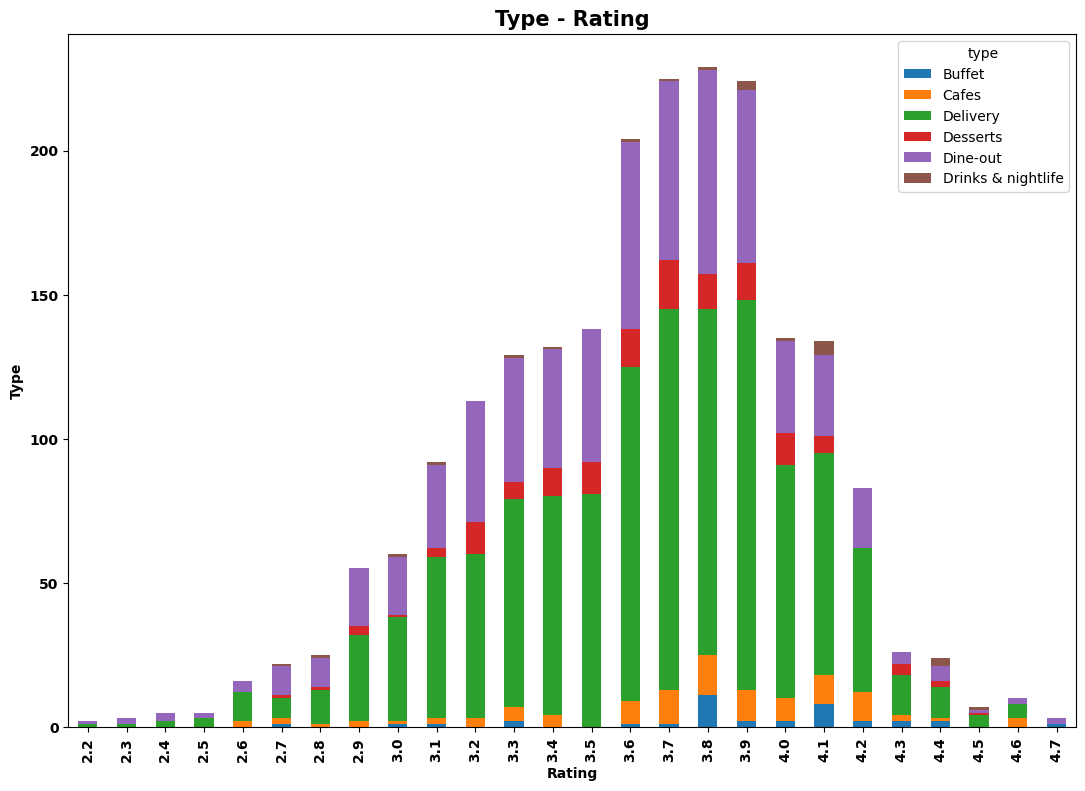

In [37]:
type_plt=pd.crosstab(zomato['rate'],zomato['type'])
type_plt.plot(kind='bar',stacked=True);
plt.title('Type - Rating',fontsize=15,fontweight='bold')
plt.ylabel('Type',fontsize=10,fontweight='bold')
plt.xlabel('Rating',fontsize=10,fontweight='bold')
plt.xticks(fontsize=10,fontweight='bold')
plt.yticks(fontsize=10,fontweight='bold');
plt.savefig('Type and Rating')

/tmp/ipython-input-536105333.py:2: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  sns.countplot(zomato['cost']).set_xticklabels(sns.countplot(zomato['cost']).get_xticklabels(), rotation=90, ha="right")


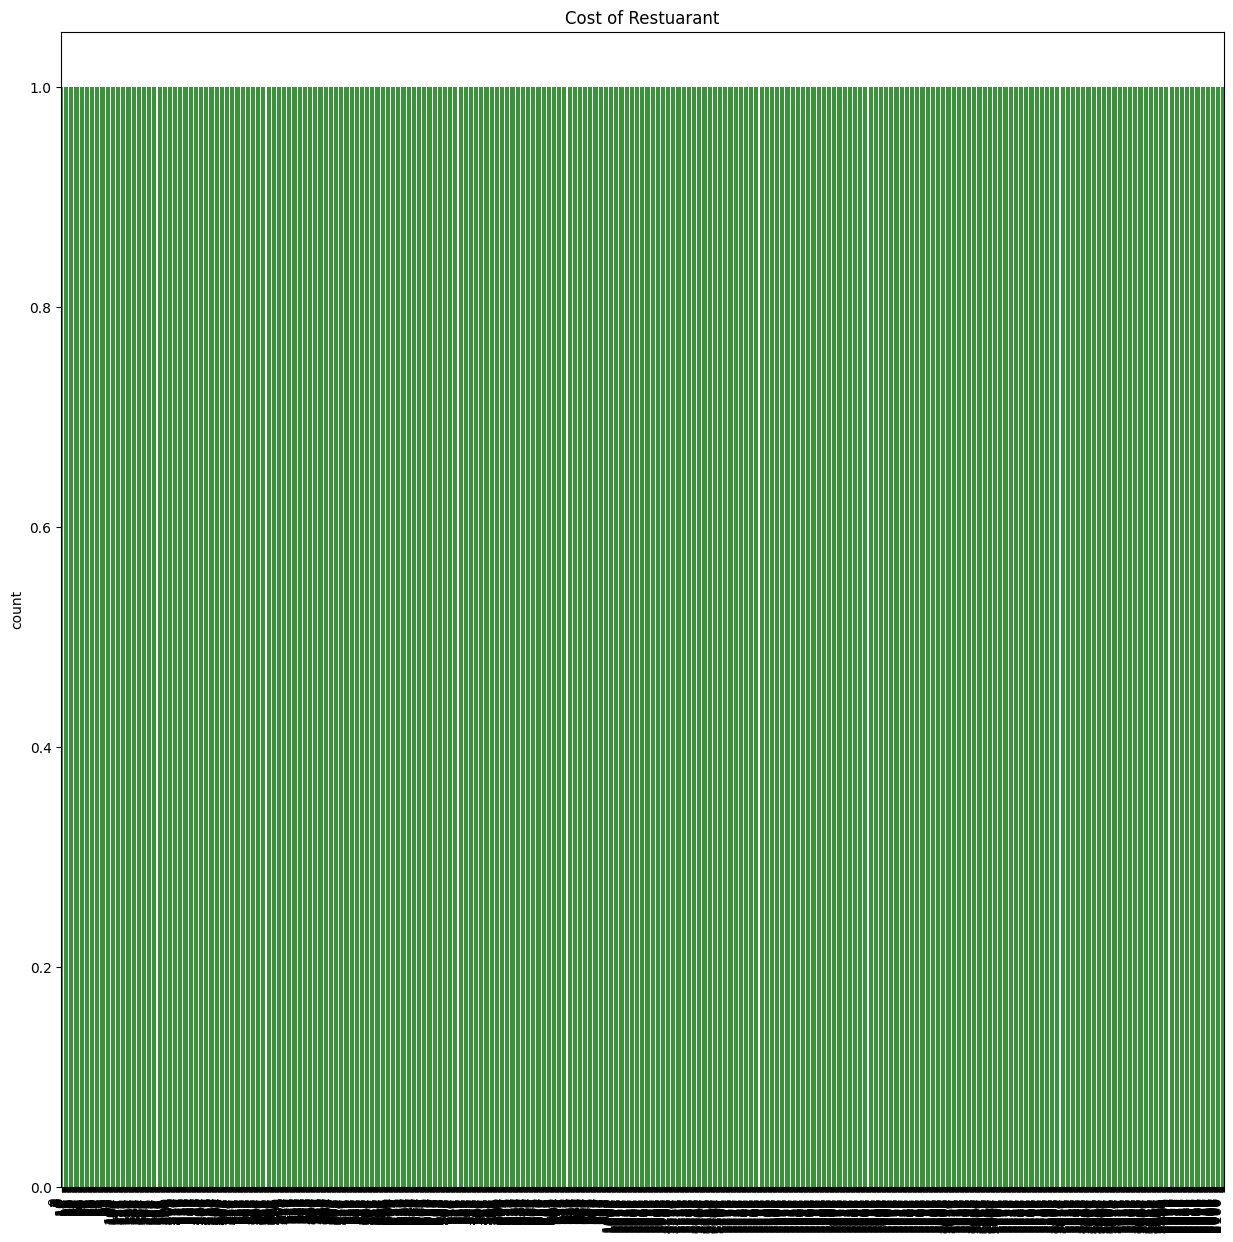

In [33]:
sns.countplot(zomato['cost'])
sns.countplot(zomato['cost']).set_xticklabels(sns.countplot(zomato['cost']).get_xticklabels(), rotation=90, ha="right")
fig = plt.gcf()
fig.set_size_inches(15,15)
plt.title('Cost of Restuarant')
plt.savefig('Cost of Restaurant')

/tmp/ipython-input-3056234562.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  loc = sns.countplot(x="location",data=zomato, palette = "Set1")
/tmp/ipython-input-3056234562.py:3: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  loc.set_xticklabels(loc.get_xticklabels(), rotation=90, ha="right")


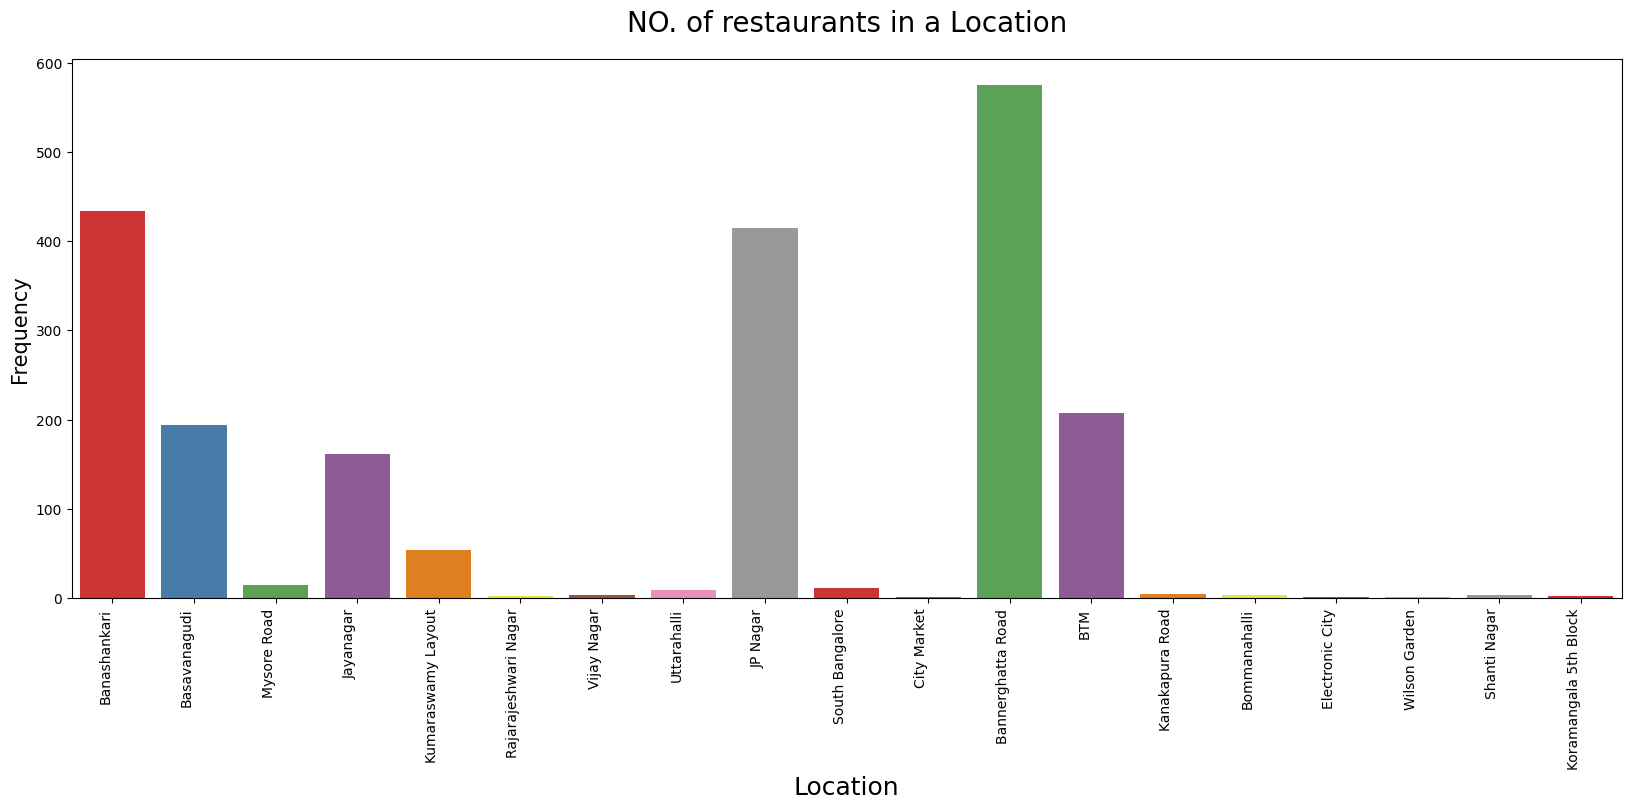

In [39]:

fig = plt.figure(figsize=(20,7))
loc = sns.countplot(x="location",data=zomato, palette = "Set1")
loc.set_xticklabels(loc.get_xticklabels(), rotation=90, ha="right")
plt.ylabel("Frequency",size=15)
plt.xlabel("Location",size=18)
loc
plt.title('NO. of restaurants in a Location',size = 20,pad=20)
plt.savefig("Restaurants in Location")

/tmp/ipython-input-1177864367.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  rest = sns.countplot(x="rest_type",data=zomato, palette = "Set1")
/tmp/ipython-input-1177864367.py:3: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  rest.set_xticklabels(rest.get_xticklabels(), rotation=90, ha="right")


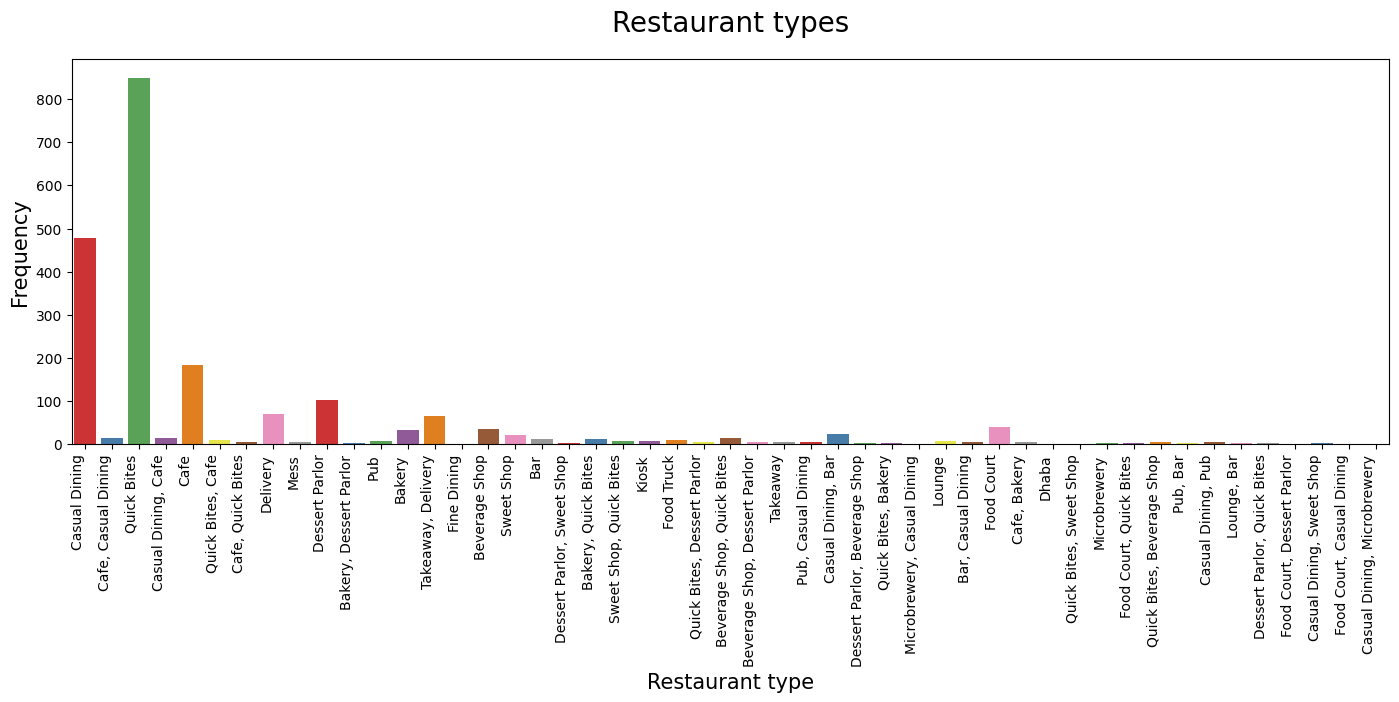

In [40]:
fig = plt.figure(figsize=(17,5))
rest = sns.countplot(x="rest_type",data=zomato, palette = "Set1")
rest.set_xticklabels(rest.get_xticklabels(), rotation=90, ha="right")
plt.ylabel("Frequency",size=15)
plt.xlabel("Restaurant type",size=15)
rest
plt.title('Restaurant types',fontsize = 20 ,pad=20)
plt.savefig('Restaurant types')

/tmp/ipython-input-791020826.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=chains,y=chains.index,palette='Set1')


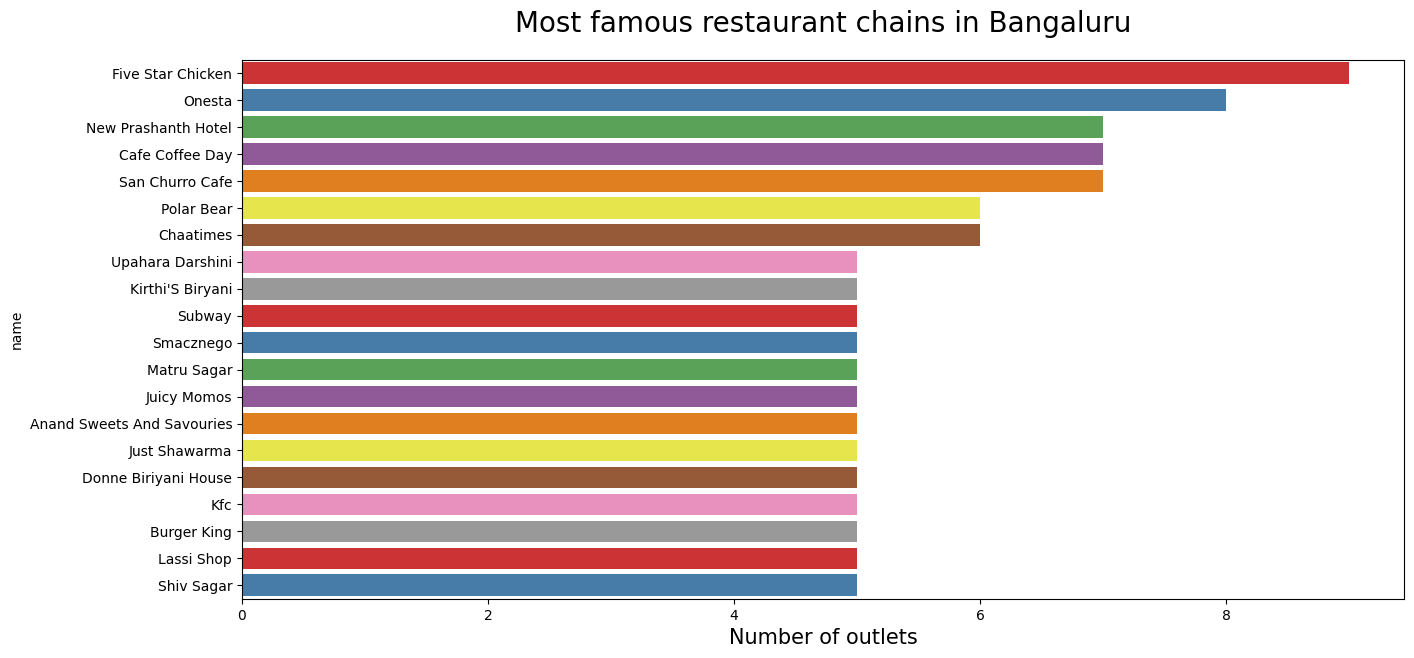

In [41]:
plt.figure(figsize=(15,7))
chains=zomato['name'].value_counts()[:20]
sns.barplot(x=chains,y=chains.index,palette='Set1')
plt.title("Most famous restaurant chains in Bangaluru",size=20,pad=20)
plt.xlabel("Number of outlets",size=15)
plt.savefig('Most famous restaurant chains')

In [42]:
# Save this as app.py
%%writefile app.py
import streamlit as st
import pandas as pd
import numpy as np
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
import pickle
import os

# Page configuration
st.set_page_config(page_title="Heart Disease Predictor", page_icon="❤️", layout="wide")

# Custom CSS
st.markdown("""
    <style>
    .main {background-color: #f0f2f6;}
    .stButton>button {background-color: #ff4b4b; color: white; border-radius: 10px;}
    .prediction-box {padding: 20px; border-radius: 10px; text-align: center;}
    </style>
""", unsafe_allow_html=True)

# Title
st.title("❤️ Heart Disease Prediction App")
st.markdown("### Enter patient details to predict heart disease risk")

# Load or create model
@st.cache_resource
def load_model():
    # For demo: creating synthetic dataset
    from sklearn.datasets import make_classification
    X, y = make_classification(n_samples=1000, n_features=7, n_classes=2, random_state=42)

    model = RandomForestClassifier(n_estimators=100, random_state=42)
    model.fit(X, y)
    return model

model = load_model()

# Sidebar inputs
st.sidebar.header("Patient Parameters")

age = st.sidebar.slider("Age", 20, 90, 50)
sex = st.sidebar.selectbox("Sex", ["Male", "Female"])
cp = st.sidebar.selectbox("Chest Pain Type", ["Typical Angina", "Atypical Angina", "Non-anginal Pain", "Asymptomatic"])
trestbps = st.sidebar.slider("Resting Blood Pressure (mm Hg)", 90, 200, 120)
chol = st.sidebar.slider("Cholesterol (mg/dl)", 100, 600, 200)
fbs = st.sidebar.selectbox("Fasting Blood Sugar > 120 mg/dl", ["No", "Yes"])
thalach = st.sidebar.slider("Max Heart Rate Achieved", 70, 220, 150)

# Convert categorical to numerical
sex_num = 1 if sex == "Male" else 0
cp_num = ["Typical Angina", "Atypical Angina", "Non-anginal Pain", "Asymptomatic"].index(cp)
fbs_num = 1 if fbs == "Yes" else 0

# Create feature array
features = np.array([[age, sex_num, cp_num, trestbps, chol, fbs_num, thalach]])

# Prediction button
if st.sidebar.button("🔍 Predict", use_container_width=True):
    prediction = model.predict(features)[0]
    probability = model.predict_proba(features)[0]

    col1, col2 = st.columns(2)

    with col1:
        st.subheader("Prediction Result")
        if prediction == 1:
            st.error("⚠️ **High Risk of Heart Disease**")
            st.progress(int(probability[1] * 100))
            st.write(f"Confidence: {probability[1]:.2%}")
        else:
            st.success("✅ **Low Risk of Heart Disease**")
            st.progress(int(probability[0] * 100))
            st.write(f"Confidence: {probability[0]:.2%}")

    with col2:
        st.subheader("Patient Summary")
        data = {
            "Parameter": ["Age", "Sex", "Chest Pain", "Blood Pressure", "Cholesterol", "Fasting Sugar", "Max Heart Rate"],
            "Value": [age, sex, cp, frestbps, chol, fbs, thalach]
        }
        st.dataframe(pd.DataFrame(data), use_container_width=True)

# Additional features
st.markdown("---")
st.subheader("📊 Model Insights")

tab1, tab2 = st.tabs(["Feature Importance", "About"])

with tab1:
    # Feature importance visualization
    import matplotlib.pyplot as plt
    fig, ax = plt.subplots()
    features_names = ['Age', 'Sex', 'Chest Pain', 'BP', 'Cholesterol', 'Fasting Sugar', 'Heart Rate']
    importances = model.feature_importances_
    ax.barh(features_names, importances, color='skyblue')
    ax.set_xlabel('Importance')
    st.pyplot(fig)

with tab2:
    st.info("""
    This application uses a Random Forest classifier to predict heart disease risk.
    **Note:** This is a demonstration app. Consult a healthcare professional for medical advice.
    """)

Writing app.py


In [44]:
# Uninstall if partially installed, then reinstall
!pip uninstall pyngrok -y
!pip install pyngrok --quiet

In [45]:
# Check if it's installed
import importlib
spec = importlib.util.find_spec("pyngrok")
print(f"pyngrok found: {spec is not None}")

# Try importing
try:
    from pyngrok import ngrok
    print("✅ Import successful!")
except ImportError as e:
    print(f"❌ Import error: {e}")

pyngrok found: True
✅ Import successful!


In [ ]:
# This will restart your Colab runtime
import os
os.kill(os.getpid(), 9)

In [5]:
!npx localtunnel --port 8501

⠙⠹⠸⠼⠴⠦⠧^C


In [4]:
!curl ifconfig.me

34.125.124.197

In [10]:
# Install and setup
!npm install -g localtunnel

# Start streamlit in background
!streamlit run app.py --server.port 8501 &>/dev/null&

# Create tunnel (prints URL)
!npx localtunnel --port 8501

⠙⠹⠸⠼⠴
changed 22 packages in 660ms
⠴
⠴3 packages are looking for funding
⠴  run `npm fund` for details
⠴⠙⠹⠸⠼⠴⠦⠧⠇⠏⠋your url is: https://nine-seas-stop.loca.lt
^C
